In [1]:
import os, sys
import glob
import numpy as np
import netCDF4 as nc
import xarray as xr

# ----------------------------
# set plotting styles
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.ioff()
rc = {"font.family": "serif",
      "mathtext.fontset": "stix"}
plt.rcParams.update(rc)
plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]
plt.rcParams.update({'font.size': 18, 'axes.labelsize': 20})
opj =os.path.join

In [16]:
idir = "/DATA/git/vrtc/mopsmap_tbx"
files=opj(idir,'scatmat','types','*.nc')

#------------------------------------
# load data
#------------------------------------
scatmat = []
for file in glob.glob(files):
    #print(file)
    name = os.path.basename(file).replace('_scatmat.nc','')
    ds = xr.open_dataset(file)
    # reset dim and coords for practical use
    ds = ds.rename({'wavelen':'wl'}).rename({'nlam':'wl','nphamat':'scamat','nthetamax':'angle'}).set_coords('wl').set_index(wl='wl')
    scaang = ds.theta.isel(wl=0,scamat=0).squeeze().values
    ds = ds.assign_coords({'angle':scaang}).drop_vars('theta')
    ds['name']=name
    #ds['rh']=rh
    scatmat.append(ds.set_coords(['name','wl']))
scamat = xr.concat(scatmat,dim='name')
scamat.sortby('name')
scamat['wl']=scamat.wl*1e3

In [3]:
#-----------------
# plot
# -----------------

cmap = mpl.colors.LinearSegmentedColormap.from_list("",
                                                    ['navy', "blue", 'lightskyblue',
                                                     'gray', 'yellowgreen', 'forestgreen','gold','darkgoldenrod','darkred','black'])

norm = mpl.colors.Normalize(vmin=0.4, vmax=2.2)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

<>:46: SyntaxWarning: invalid escape sequence '\ '
<>:46: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_627340/2779250613.py:46: SyntaxWarning: invalid escape sequence '\ '
  cb.set_label('$Wavelength\ (\mu m)$', fontsize=22)


SUSO rh0


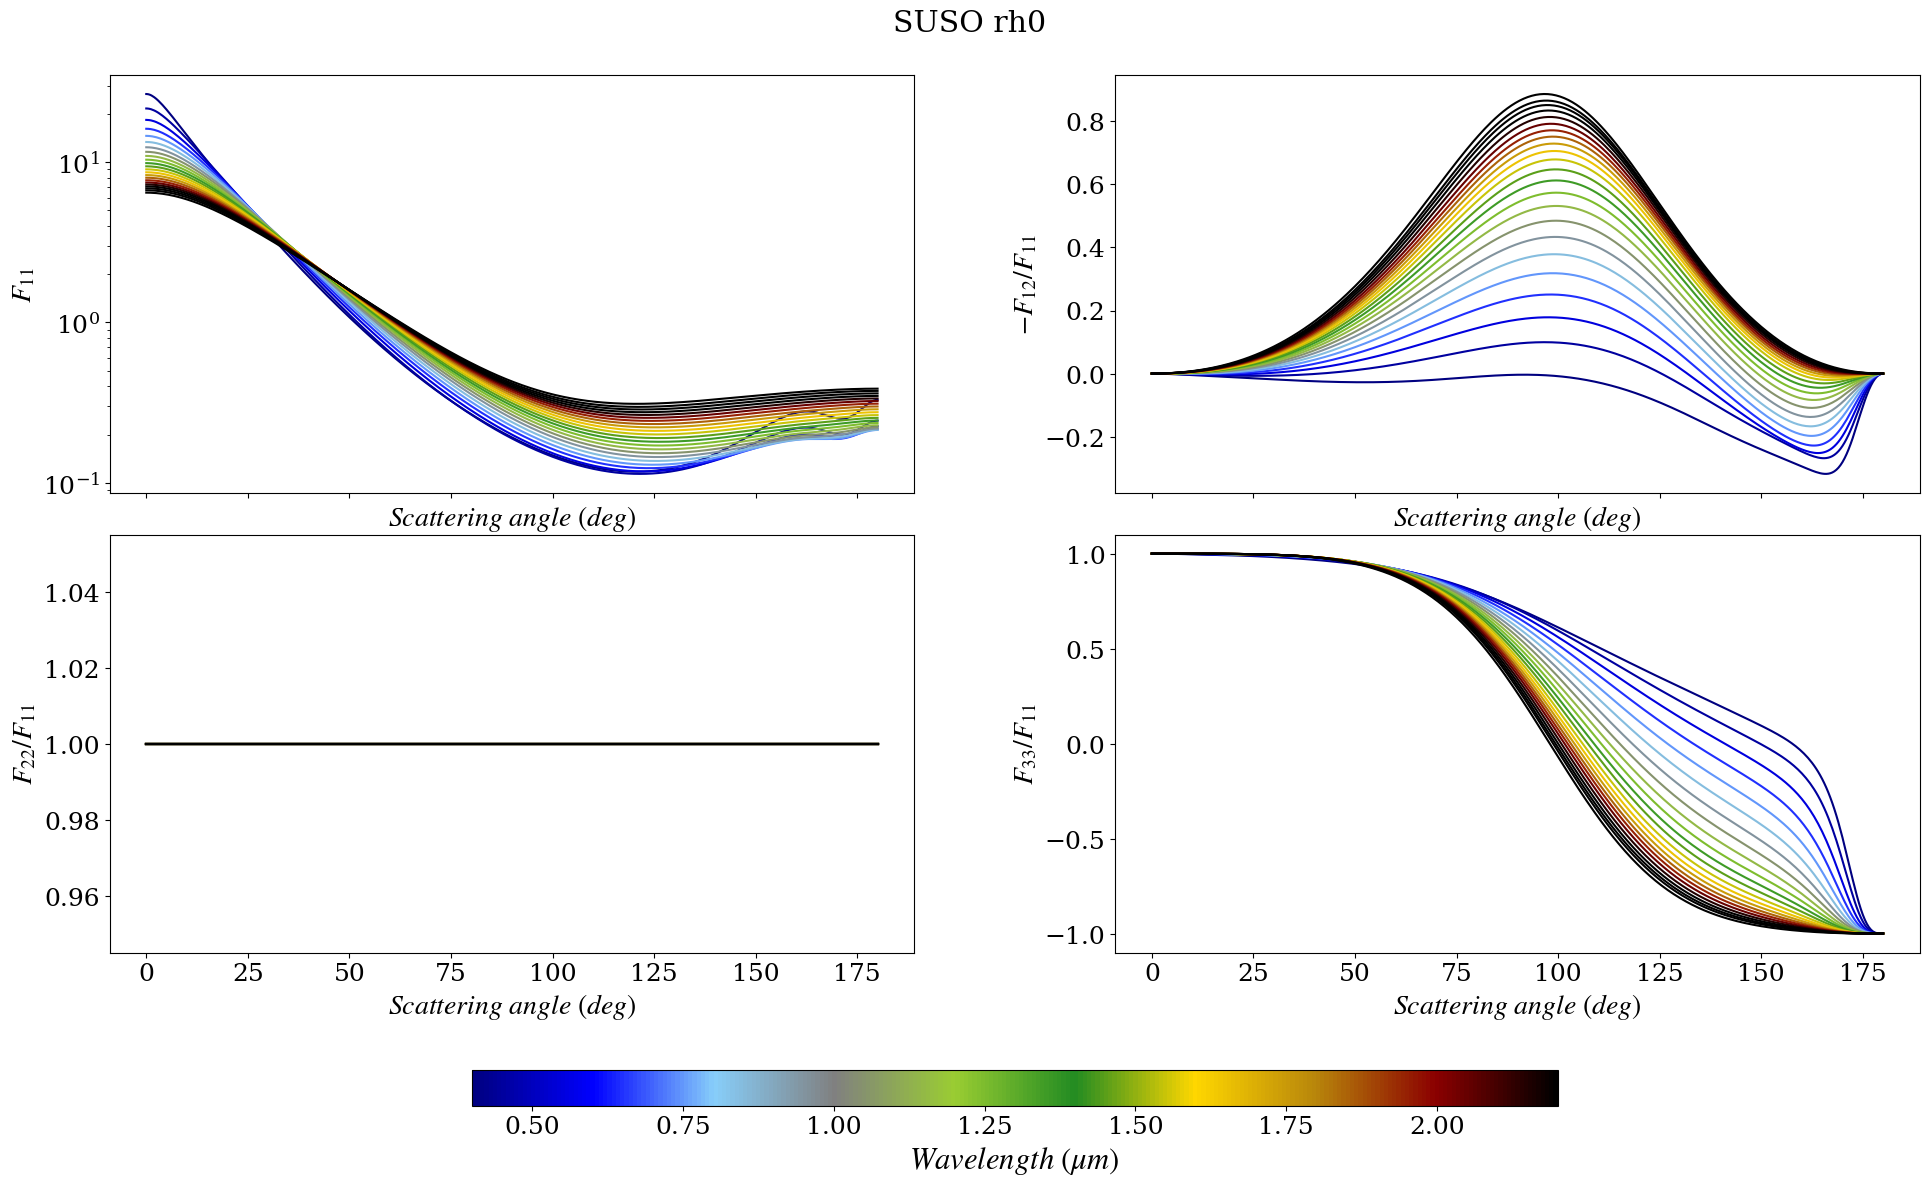

SUSO rh50


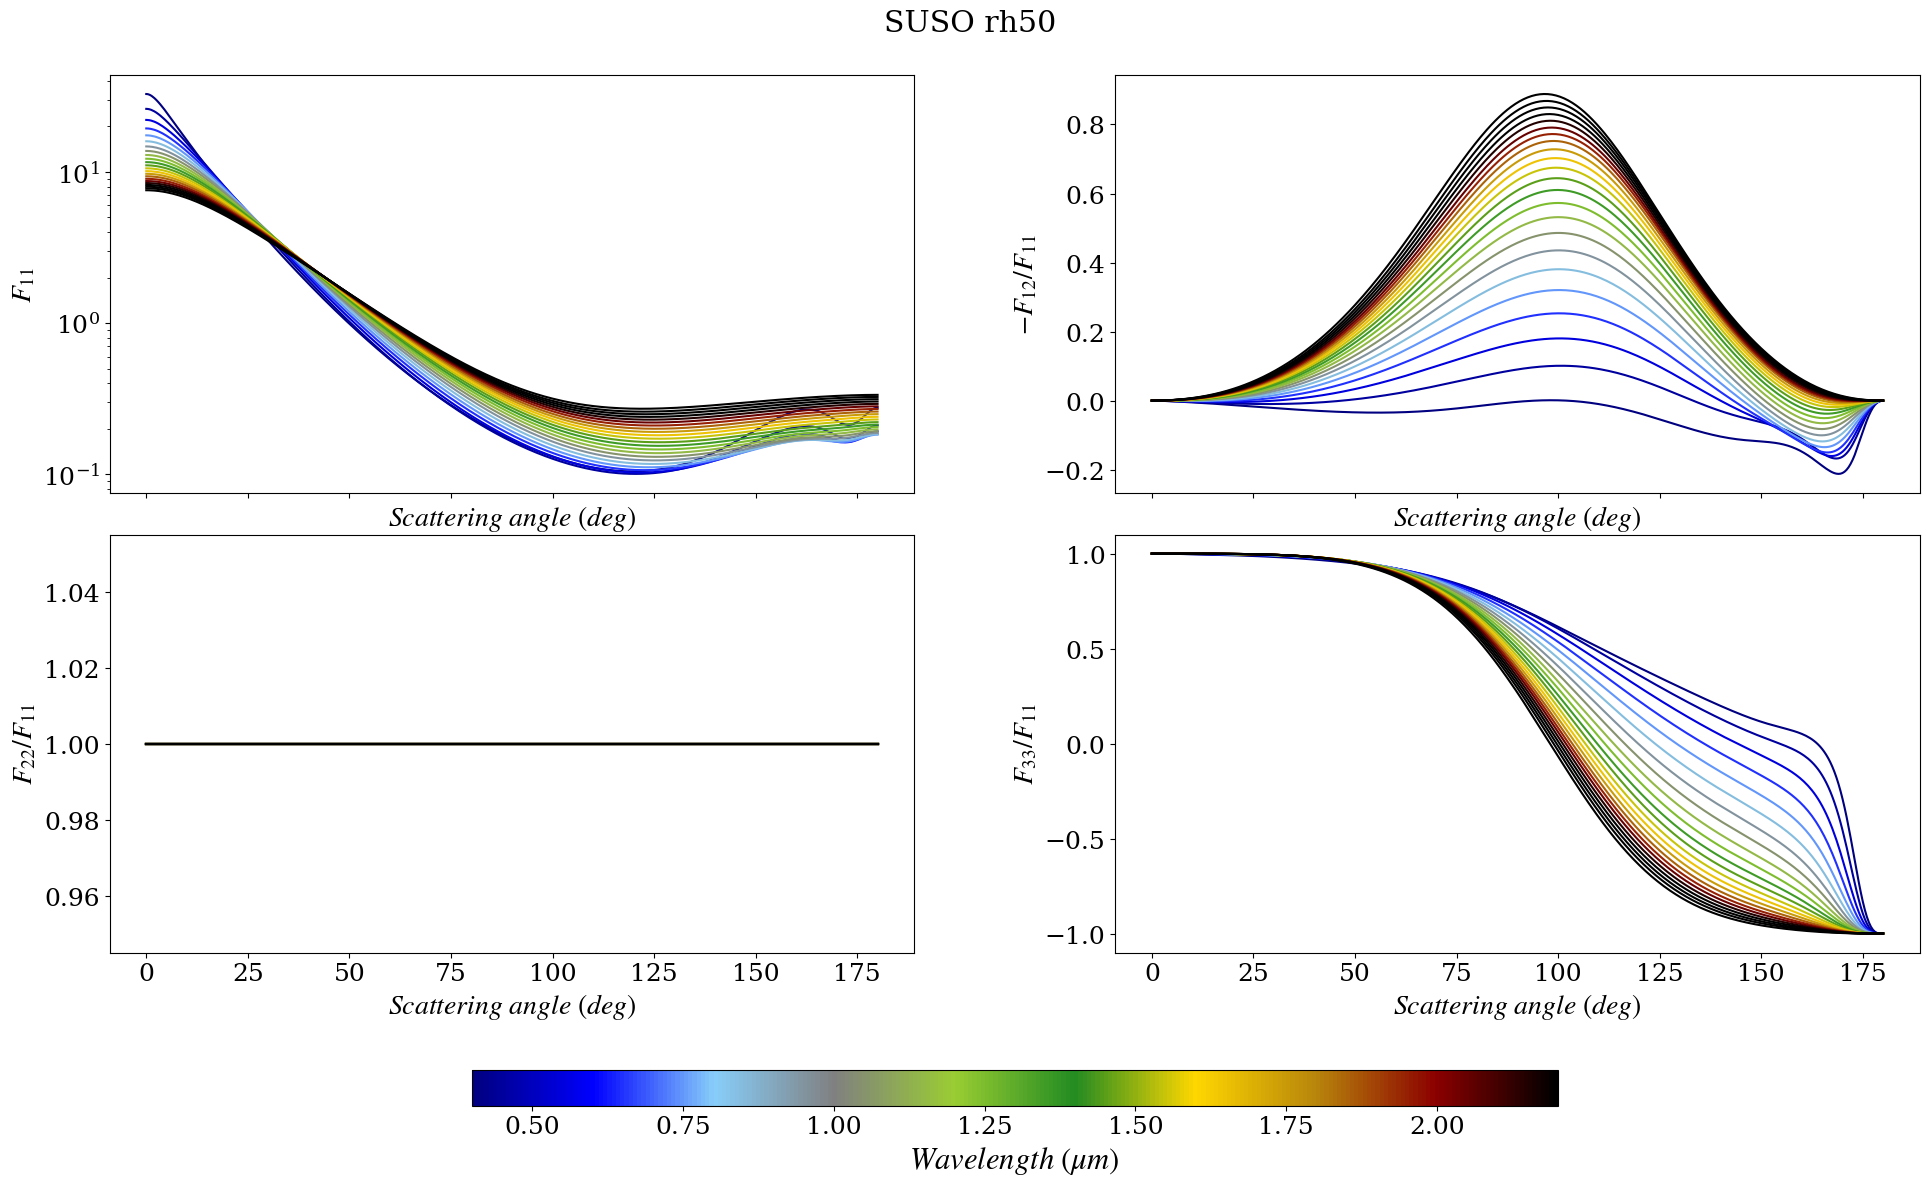

SUSO rh70


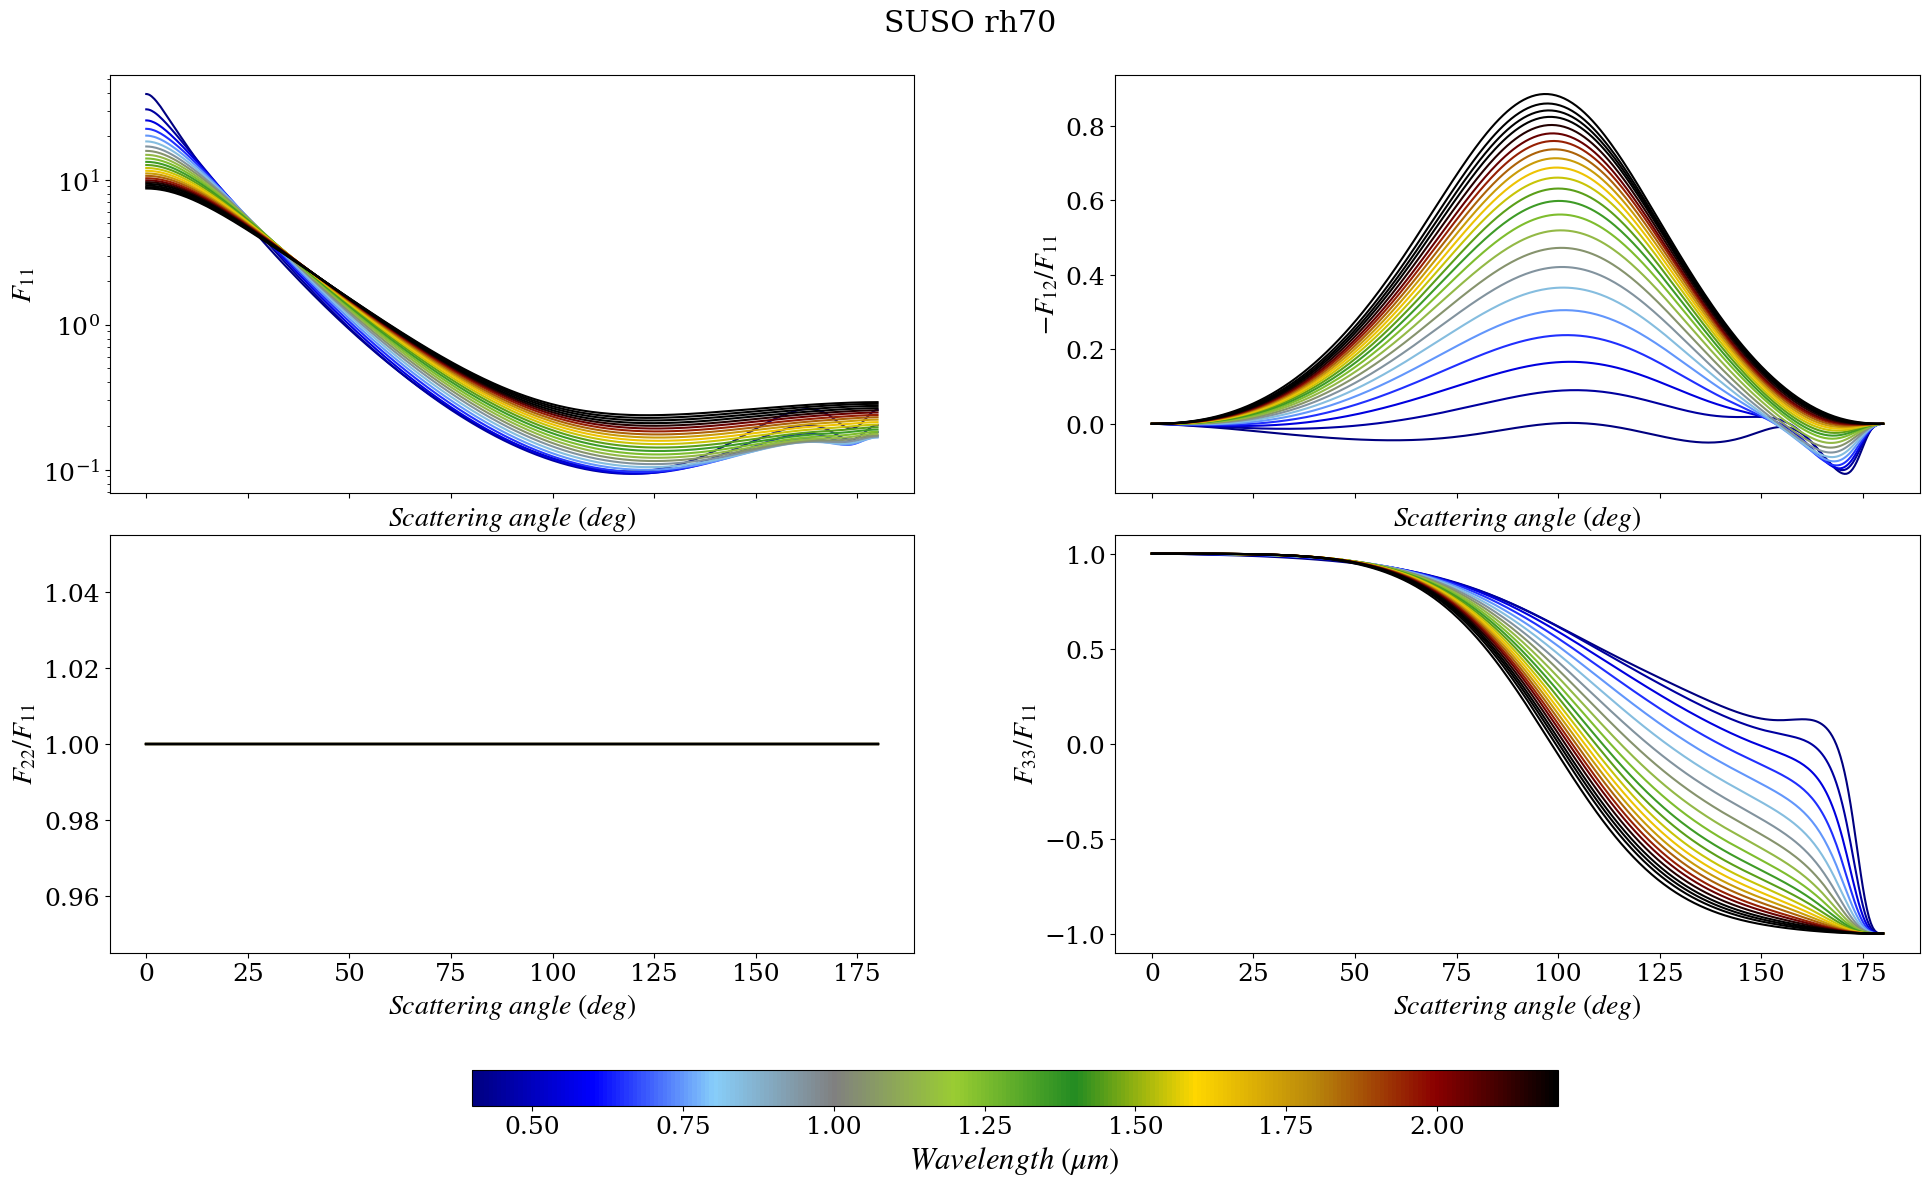

In [ ]:
#--------------------------
# plot scattering matrix
#--------------------------
for name,ds_ in scamat.sel(name="SUSO").groupby('name'):
    for rh,ds in ds_.groupby('rh'):
        print(name,rh)
        ds = ds.squeeze()
        fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(20, 12), sharex=True)
        fig.subplots_adjust(bottom=-0.05, top=0.925, left=0.07, right=0.975,
                            hspace=0.1, wspace=0.25)
        axs = axs.ravel()
        for wl in ds.wl.values[::2]:
              ds_ = ds.sel(wl=wl).squeeze()
              f11 = ds_.phase.isel(scamat=0)
              axs[0].plot(ds_.angle,ds_.phase.isel(scamat=0),color=cmap(norm(wl)))
              # -F12/F11
              axs[1].plot(ds_.angle,-ds_.phase.isel(scamat=1)/f11,color=cmap(norm(wl)))
              # F22/F11
              axs[2].plot(ds_.angle,ds_.phase.isel(scamat=4)/f11,color=cmap(norm(wl)))
              # F33/F11
              axs[3].plot(ds_.angle,ds_.phase.isel(scamat=2)/f11,color=cmap(norm(wl)))

        for i in range(4):
            axs[i].set_xlabel(r'$Scattering\ angle\ (deg)$')
        axs[0].semilogy()
        axs[0].set_ylabel(r'$F_{11}$')
        axs[1].set_ylabel(r'$-F_{12}/F_{11}$')
        axs[2].set_ylabel(r'$F_{22}/F_{11}$')
        axs[3].set_ylabel(r'$F_{33}/F_{11}$')
        plt.suptitle(name+' '+rh)

        cb = fig.colorbar(sm, ax=axs, shrink=0.6, aspect=30, pad=0.1, location='bottom')
        cb.set_label('$Wavelength\ (\mu m)$', fontsize=22)
        #plt.savefig(opj(dirfig,'OPAC_types',name+'_'+rh+'_scatmat.png'),dpi=300)
        #plt.close()
        plt.show()

In [11]:
scamat#.sel(name='WASO').set_coords('rh')

<xarray.Dataset>
Dimensions:  (name: 86, nreff: 1, wl: 46, scamat: 6, angle: 376, nmommax: 129)
Coordinates:
  * wl       (wl) float64 0.35 0.4 0.45 0.5 0.55 0.6 ... 2.4 2.45 2.5 2.55 2.6
  * angle    (angle) float32 180.0 179.5 179.0 178.5 ... 0.01 0.005 0.001 0.0
  * name     (name) <U4 'COAV' 'COAV' 'MATR' 'COPO' ... 'ARCT' 'MAPO' 'SUSO'
    rh       (name) <U4 'rh70' 'rh50' 'rh50' 'rh50' ... 'rh98' 'rh80' 'rh50'
Dimensions without coordinates: nreff, scamat, nmommax
Data variables:
    reff     (name, nreff) float64 0.1974 0.1995 0.6757 ... 0.7109 0.5657 0.2804
    phase    (name, wl, nreff, scamat, angle) float32 0.2714 0.2709 ... 7.446
    pmom     (name, wl, nreff, scamat, nmommax) float32 1.0 2.055 ... -1.01e-16
    nmom     (name, wl, nreff, scamat) int32 129 129 129 129 ... 129 129 129 129
    ntheta   (name, wl, nreff, scamat) int32 376 376 376 376 ... 376 376 376 376
    ext      (name, wl, nreff) float64 0.005386 0.00465 ... 0.005513 0.005622
    ssa      (name, wl, nreff) float64 0.8969 0.8948 0.8922 ... 0.8192 0.7138
    rho      (name, nreff) float64 2.274 2.442 1.789 2.417 ... 1.069 1.366 2.046
Attributes:
    file_info:         Netcdf file created using mopsmap
    version:           20090626
    parameterization:  Mie, T-matrix method, geometric optics

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ARCT_rh70
COAV_rh70
DESE_rh70
MACL_rh70
URBA_rh70
WASO_rh0


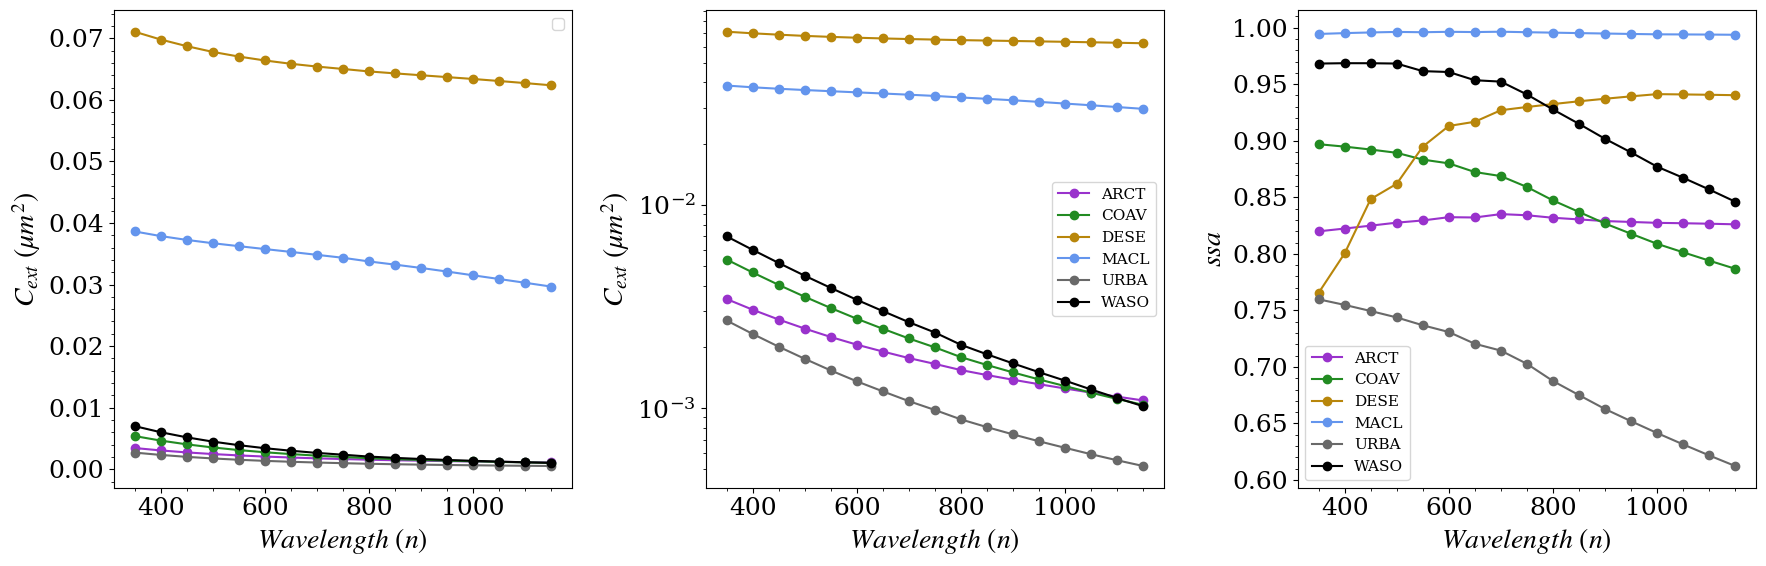

In [23]:
#--------------------------
# plot Cext, SSA spectra
#--------------------------
names = ['ARCT_rh70','COAV_rh70','DESE_rh70','MACL_rh70','URBA_rh70','WASO_rh0']
colors = {'COAV': 'forestgreen', 'COPO': 'olivedrab', 'COCL': 'yellowgreen',
          'DESE': 'darkgoldenrod', 'MACL': 'cornflowerblue', 'MAPO': 'mediumblue', 'URBA': 'dimgrey',
          'ARCT': 'darkorchid', 'ANTA': 'palevioletred','MATR':'steelblue','WASO':'k','SUSO':'red'}

# Rel. humidity = 0
suff=''
#suff ='_norm'
fig, axs = plt.subplots(ncols=3, nrows=1, figsize=(18, 6), sharex=True)
fig.subplots_adjust(bottom=0.15, top=0.925, left=0.1, right=0.975,
                    hspace=0.1, wspace=0.25)
axs = axs.ravel()

for name in names:
    ds=scamat.sel(name=name).sel(wl=slice(350,1200))
    name_, __ = name.split('_')   
    print(name)
    ds = ds.squeeze()
    if suff == '_norm':
        Cext_550 = ds.ext.interp(wl=550)
    else:
        Cext_550 = 1.
    axs[0].plot(ds.wl, ds.ext / Cext_550, 'o-', color=colors[name_])
    axs[1].plot(ds.wl, ds.ext / Cext_550, 'o-', color=colors[name_], label=name_)
    axs[2].plot(ds.wl, ds.ssa, 'o-', color=colors[name_], label=name_)
for i in range(3):
    axs[i].set_xlabel(r'$Wavelength\ (n)$')
    axs[i].legend(fontsize=11)
if suff == '_norm':
    ylabel=r'$C_{ext}/C_{ext}(550nm)$'
else:
    ylabel=r'$C_{ext}\ (\mu m^2)$'
axs[0].set_ylabel(ylabel)
axs[1].set_ylabel(ylabel)

axs[1].semilogy()
axs[2].set_ylabel('$ssa$')
for ax in axs:
    ax.minorticks_on()
plt.tight_layout()
plt.savefig('/DATA/projet/magellium/esa/phy2flex/fig/AC/spectral_prop_aerosol_OPAC.png', dpi=300,bbox_inches='tight')
#plt.close()
plt.show()

In [11]:
ds=scamat
wl1,wl2=0.440,0.865
ds.ext.interp(wl=wl1)
ds.ext.interp(wl=wl2)

ang_exp=-(np.log(ds.ext.interp(wl=wl1)/ds.ext.interp(wl=wl2))/np.log(wl1/wl2)).squeeze()
ang_exp.to_dataframe().T
ang_exp.sel(name='URBA').sortby('rh')

<xarray.DataArray 'ext' (name: 8)> Size: 64B
array([1.39963632, 1.41594759, 1.42847191, 1.43454005, 1.42041714,
       1.35191576, 1.17439715, 0.99366716])
Coordinates:
  * name     (name) <U4 128B 'URBA' 'URBA' 'URBA' ... 'URBA' 'URBA' 'URBA'
    rh       (name) <U4 128B 'rh0' 'rh50' 'rh70' 'rh80' ... 'rh95' 'rh98' 'rh99'

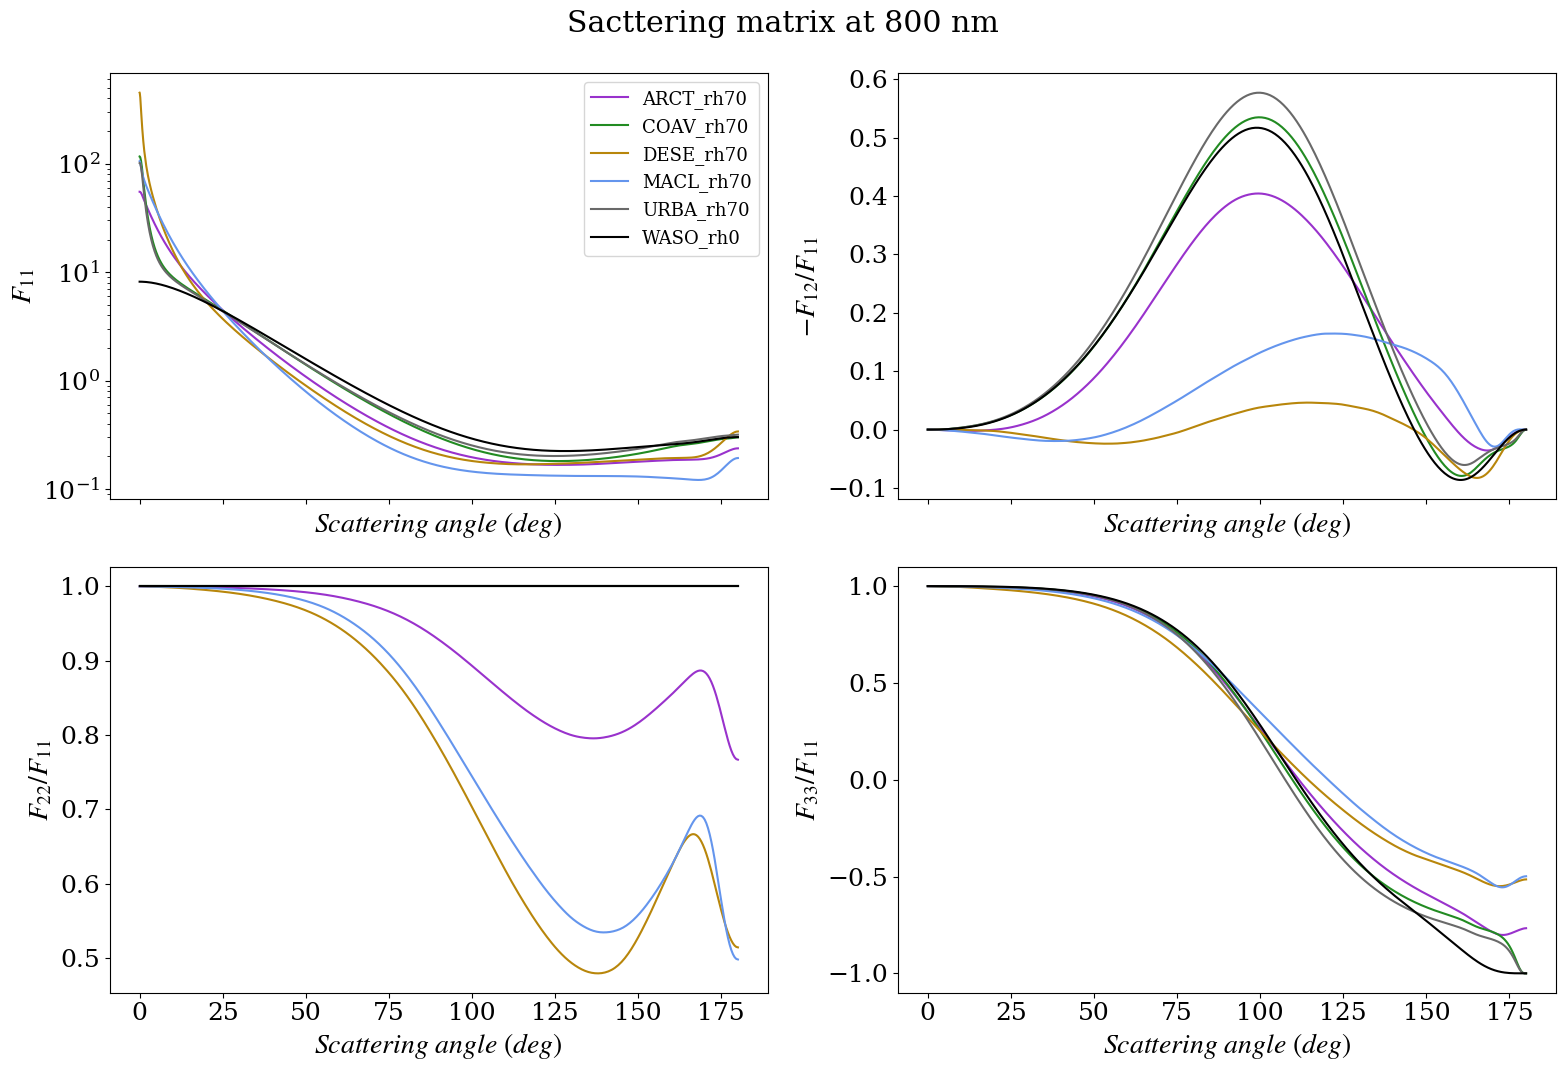

In [31]:
#--------------------------
# plot scattering matrix
wl=800
fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(16, 11), sharex=True)
fig.subplots_adjust(bottom=0.15, top=0.925, left=0.1, right=0.975,
                        hspace=0.1, wspace=0.25) 
axs = axs.ravel()

scamat_ = scamat.sel(wl=wl)
for name in names:
    ds_=scamat_.sel(name=name) 
    name_, __ = name.split('_')   
    
   
    ds_ = ds_.squeeze()

    f11 = ds_.phase.isel(scamat=0)
    axs[0].plot(ds_.angle, ds_.phase.isel(scamat=0), color=colors[name_],label=name)
    # -F12/F11
    axs[1].plot(ds_.angle, -ds_.phase.isel(scamat=1) / f11, color=colors[name_],label=name)
    # F22/F11
    axs[2].plot(ds_.angle, ds_.phase.isel(scamat=4) / f11, color=colors[name_],label=name)
    # F33/F11
    axs[3].plot(ds_.angle, ds_.phase.isel(scamat=2) / f11, color=colors[name_],label=name)

for i in range(4):
    axs[i].set_xlabel('$Scattering\ angle\ (deg)$')
axs[0].semilogy()
axs[0].legend(fontsize=13)
axs[0].set_ylabel('$F_{11}$')
axs[1].set_ylabel('$-F_{12}/F_{11}$')
axs[2].set_ylabel('$F_{22}/F_{11}$')
axs[3].set_ylabel('$F_{33}/F_{11}$')
plt.suptitle('Sacttering matrix at '+str(wl)+' nm')

plt.tight_layout()

plt.savefig('/DATA/projet/magellium/esa/phy2flex/fig/AC/scatt_mat_aerosol_OPAC_'+str(wl)+'nm.png', dpi=300,bbox_inches='tight')
#plt.close()
plt.show()

<>:35: SyntaxWarning: invalid escape sequence '\ '
<>:35: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_627340/532073988.py:35: SyntaxWarning: invalid escape sequence '\ '
  axs[i].set_xlabel('$Scattering\ angle\ (deg)$')


ANTA
rh0
ARCT
rh0
COAV
rh0
COCL
rh0
COPO
rh0
DESE
rh0
MACL
rh0
MAPO
rh0
MATR
rh0
URBA
rh0
WASO
rh0


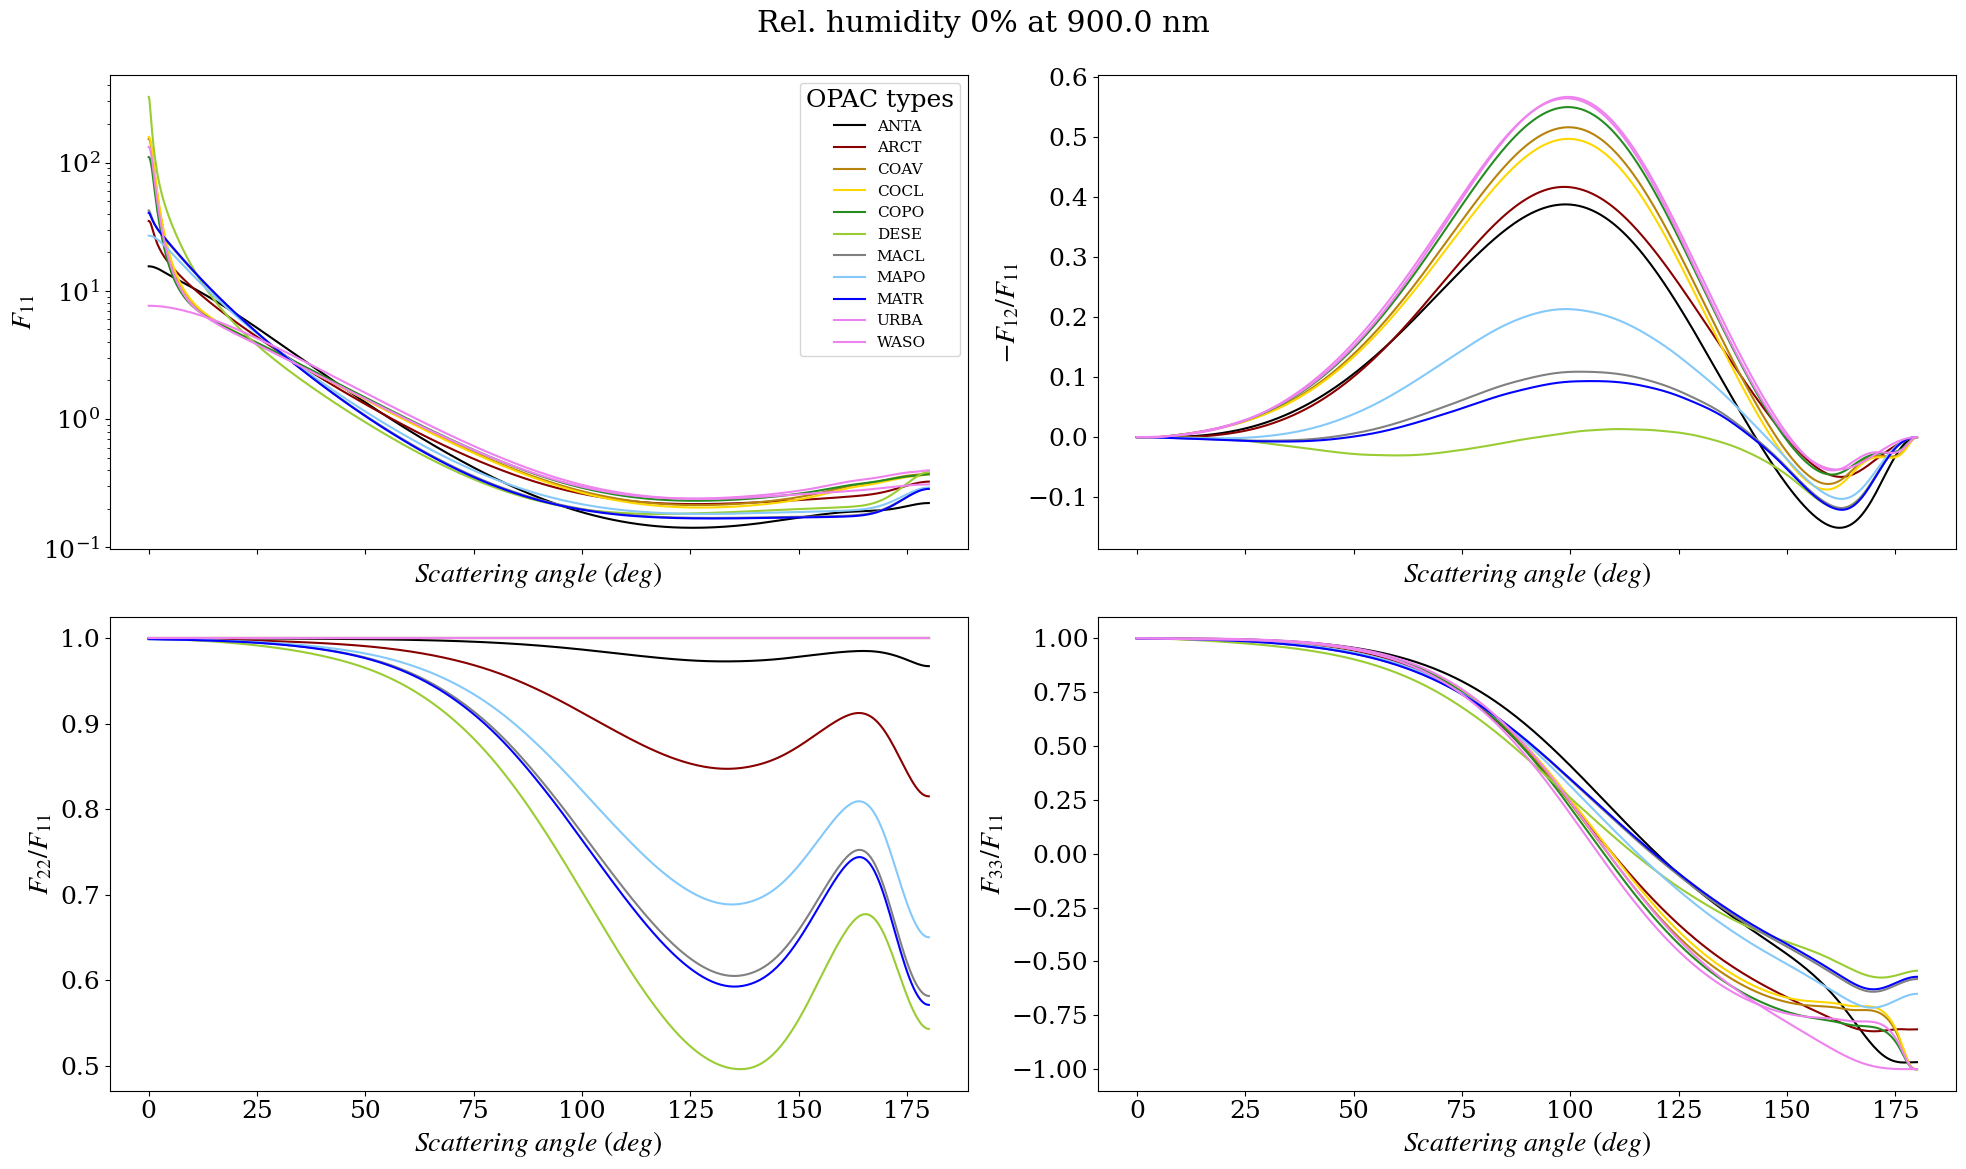

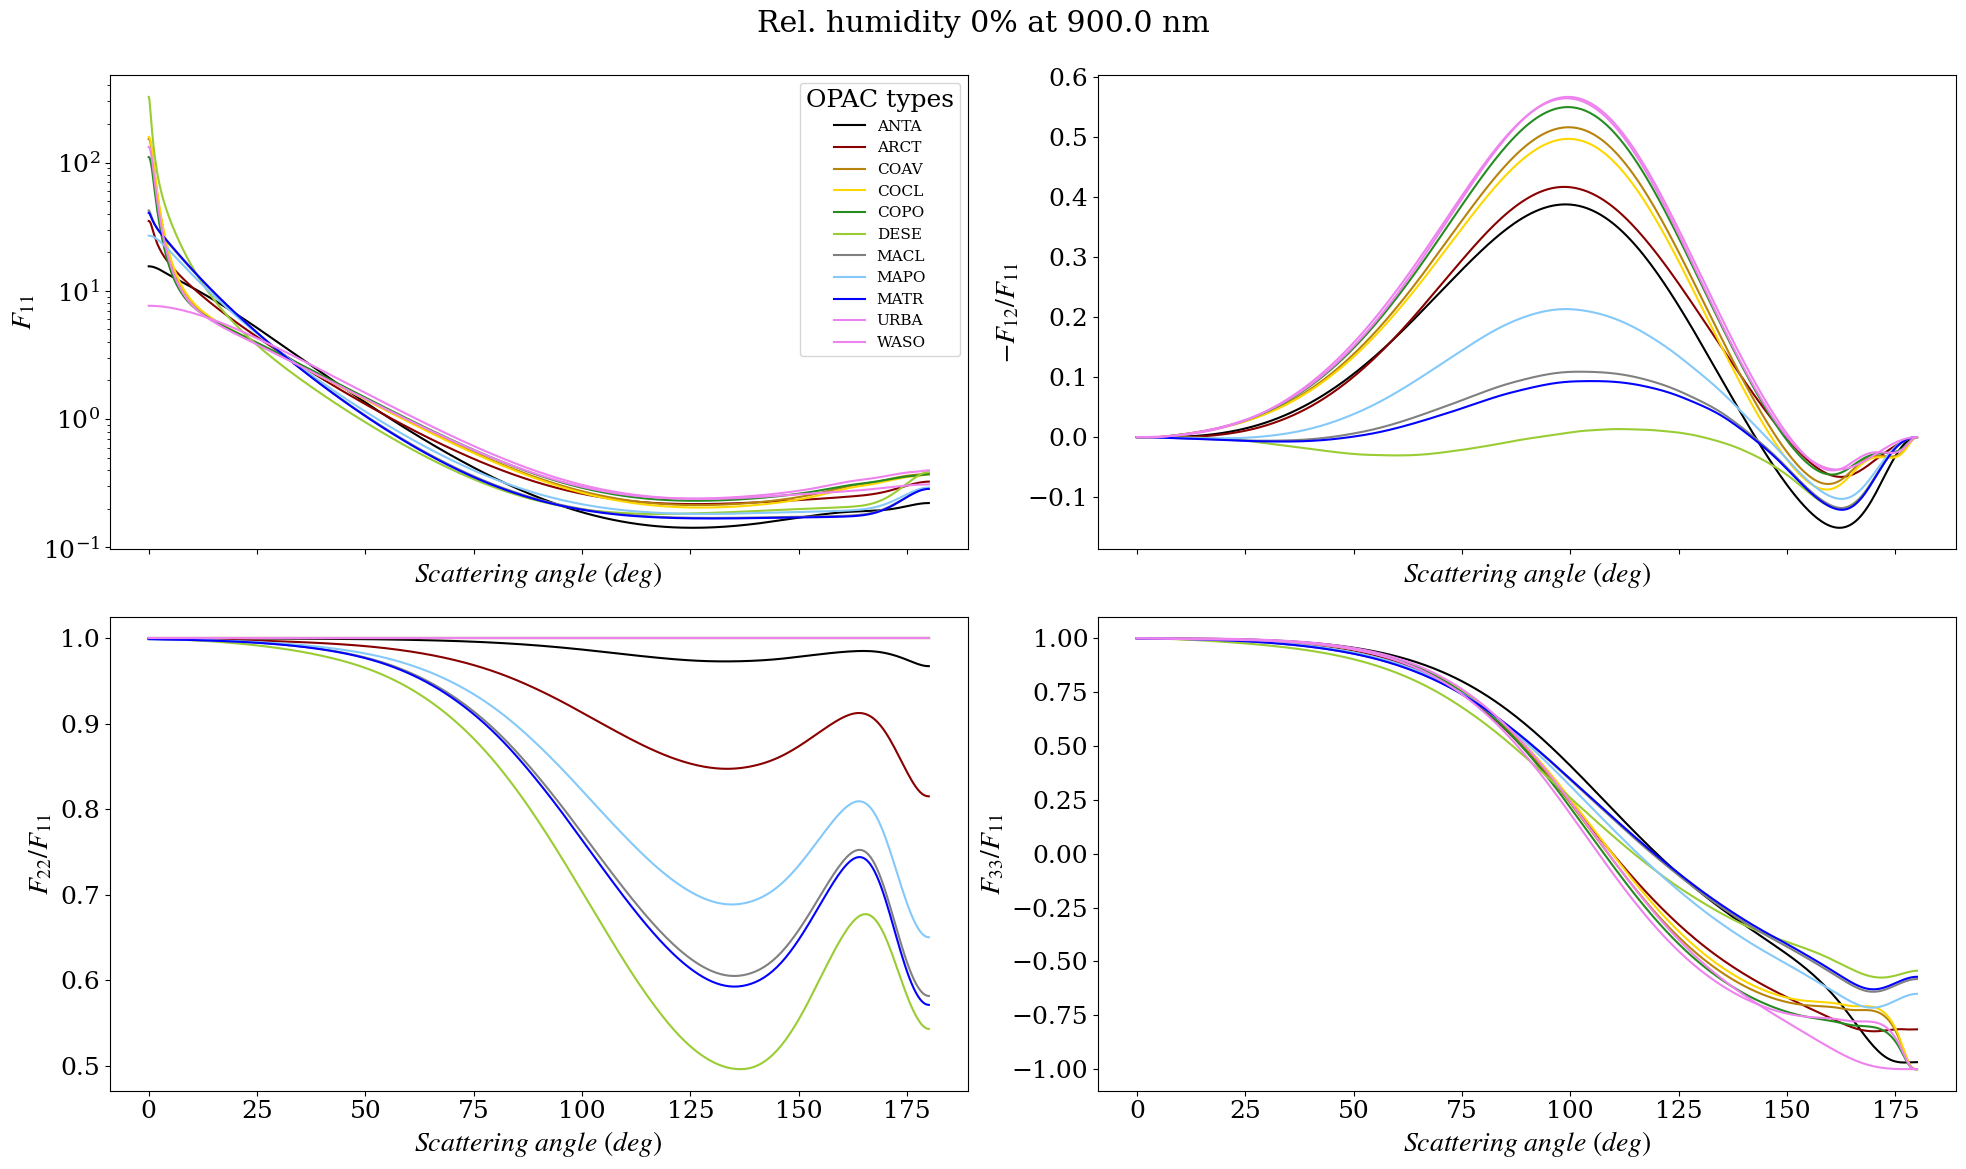

In [81]:
cmap = mpl.colors.LinearSegmentedColormap.from_list("",
                                                    ['violet', "blue", 'lightskyblue',
                                                     'gray', 'yellowgreen', 'forestgreen','gold','darkgoldenrod','darkred','black']).reversed()

norm = mpl.colors.Normalize(vmin=0, vmax=9)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(20, 12), sharex=True)
fig.subplots_adjust(bottom=0.15, top=0.925, left=0.1, right=0.975,
                    hspace=0.1, wspace=0.25)
axs = axs.ravel()
rh='rh0'
wl=0.900
scamat_ = scamat.sel(wl=wl).where(scamat.rh==rh,drop=True)
for itype,(name,ds) in enumerate(scamat_.groupby('name')):

    print(name)

    for irh,(rh,ds_) in enumerate(ds.groupby('rh')):
        print(rh)
        rel_hum=(rh.replace('rh',''))+'%'
        ds_ = ds_.squeeze()

        f11 = ds_.phase.isel(scamat=0)
        axs[0].plot(ds_.angle, ds_.phase.isel(scamat=0), color=cmap(norm(itype)),label=name)
        # -F12/F11
        axs[1].plot(ds_.angle, -ds_.phase.isel(scamat=1) / f11, color=cmap(norm(itype)),label=name)
        # F22/F11
        axs[2].plot(ds_.angle, ds_.phase.isel(scamat=4) / f11, color=cmap(norm(itype)),label=name)
        # F33/F11
        axs[3].plot(ds_.angle, ds_.phase.isel(scamat=2) / f11, color=cmap(norm(itype)),label=name)


for i in range(4):
    axs[i].set_xlabel('$Scattering\ angle\ (deg)$')
axs[0].semilogy()
axs[0].legend(title='OPAC types',fontsize=11)
axs[0].set_ylabel('$F_{11}$')
axs[1].set_ylabel('$-F_{12}/F_{11}$')
axs[2].set_ylabel('$F_{22}/F_{11}$')
axs[3].set_ylabel('$F_{33}/F_{11}$')
plt.suptitle('Rel. humidity '+rel_hum+' at '+str(wl*1000)+' nm')

plt.tight_layout()
#plt.savefig(opj('./fig/OPAC_types','scatmat_all_'+rh+'_'+str(int(wl*1000))+'nm.png'),dpi=300)
#plt.close()
plt.show()